# Inspect the extracted tables

I checked the number of rows, missing values, and locations of the tables and it all seemed correct. I also visually checked the raster stack and it seemed correct.

## Inspect modis/wgs84 table

In [24]:
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import rasterio


pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(400)

polars.config.Config

In [15]:
# Path to parquet file
# parquet_file = Path('/Volumes/TOSHIBA EXT/non-equilibrium/data/tables/2001.parquet')
parquet_file = Path('/Users/Wanja/Documents/non-equilibrium_data/tables_modis_new/table_modis_2002.parquet')
parquet_file = Path('/Users/Wanja/Documents/non-equilibrium_data/tables_wgs84_new/table_wgs84_2002.parquet')

# Load one year
df = pl.read_parquet(parquet_file)

In [16]:
# --------------------------------------------------
# Basic information
# --------------------------------------------------

print("=" * 60)
print("Dataset overview")
print("=" * 60)

print(f"Rows: {df.height:,}")
print(f"Columns: {df.width}")

print("\nColumns:")
print(df.columns)


# --------------------------------------------------
# Data types
# --------------------------------------------------

print("\nData types:")
print(df.schema)


# --------------------------------------------------
# First rows
# --------------------------------------------------

print("\nFirst rows:")
print(df.head())


# --------------------------------------------------
# Missing values
# --------------------------------------------------

print("\nMissing values:")
print(
    df.null_count()
)


# --------------------------------------------------
# Summary statistics
# --------------------------------------------------

print("\nSummary:")
print(
    df.describe()
)

Dataset overview
Rows: 4,218,230
Columns: 26

Columns:
['tmmn_mean', 'tmmx_mean', 'tmmn_min', 'tmmn_max', 'tmmx_min', 'tmmx_max', 'pr_sum', 'veg_tmmn_mean', 'veg_tmmx_mean', 'veg_tmmn_min', 'veg_tmmn_max', 'veg_tmmx_min', 'veg_tmmx_max', 'veg_pr_sum', 'vegetation_length', 'Gpp', 'Npp', 'Npp_QC', 'elevation_mean', 'longitude', 'latitude', 'year', 'iso3', 'name', 'continent', 'region']

Data types:
Schema({'tmmn_mean': Float32, 'tmmx_mean': Float32, 'tmmn_min': Float32, 'tmmn_max': Float32, 'tmmx_min': Float32, 'tmmx_max': Float32, 'pr_sum': Float32, 'veg_tmmn_mean': Float32, 'veg_tmmx_mean': Float32, 'veg_tmmn_min': Float32, 'veg_tmmn_max': Float32, 'veg_tmmx_min': Float32, 'veg_tmmx_max': Float32, 'veg_pr_sum': Float32, 'vegetation_length': Float32, 'Gpp': Float32, 'Npp': Float32, 'Npp_QC': Float32, 'elevation_mean': Float32, 'longitude': Float64, 'latitude': Float64, 'year': Int16, 'iso3': String, 'name': String, 'continent': String, 'region': String})

First rows:
shape: (5, 26)
┌───

In [18]:
print("\nLongitude range:")
print(
    df.select(
        pl.col("longitude").alias("min_lon").min(),
        pl.col("longitude").alias("max_lon").max()
    )
)

print("\nLatitude range:")
print(
    df.select(
        pl.col("latitude").alias("min_lat").min(),
        pl.col("latitude").alias("max_lat").max()
    )
)


Longitude range:
shape: (1, 2)
┌─────────────┬────────────┐
│ min_lon     ┆ max_lon    │
│ ---         ┆ ---        │
│ f64         ┆ f64        │
╞═════════════╪════════════╡
│ -179.977522 ┆ 179.977522 │
└─────────────┴────────────┘

Latitude range:
shape: (1, 2)
┌────────────┬───────────┐
│ min_lat    ┆ max_lat   │
│ ---        ┆ ---       │
│ f64        ┆ f64       │
╞════════════╪═══════════╡
│ -55.991508 ┆ 83.099401 │
└────────────┴───────────┘


In [19]:
print("\nNumber of regions:")
print(
    df.select(
        pl.col("region").n_unique()
    )
)

print("\nTop regions:")
print(
    df.group_by("region")
      .len()
      .sort("len", descending=True)
      .head(20)
)


Number of regions:
shape: (1, 1)
┌────────┐
│ region │
│ ---    │
│ u32    │
╞════════╡
│ 22     │
└────────┘

Top regions:
shape: (20, 2)
┌───────────────────────────┬─────────┐
│ region                    ┆ len     │
│ ---                       ┆ ---     │
│ str                       ┆ u32     │
╞═══════════════════════════╪═════════╡
│ Eastern Europe            ┆ 1003629 │
│ Northern America          ┆ 893361  │
│ South America             ┆ 400608  │
│ Australia and New Zealand ┆ 304095  │
│ Eastern Asia              ┆ 295643  │
│ …                         ┆ …       │
│ Northern Africa           ┆ 44889   │
│ Western Asia              ┆ 43218   │
│ Southern Europe           ┆ 35601   │
│ Western Europe            ┆ 24760   │
│ Caribbean                 ┆ 4716    │
└───────────────────────────┴─────────┘


In [20]:
print(
    df.select(
        [
            "Npp",
            "elevation_mean",
            "tmmn_mean",
            "pr_sum"
        ]
    ).describe()
)

shape: (9, 5)
┌────────────┬──────────────┬────────────────┬────────────┬─────────────┐
│ statistic  ┆ Npp          ┆ elevation_mean ┆ tmmn_mean  ┆ pr_sum      │
│ ---        ┆ ---          ┆ ---            ┆ ---        ┆ ---         │
│ str        ┆ f64          ┆ f64            ┆ f64        ┆ f64         │
╞════════════╪══════════════╪════════════════╪════════════╪═════════════╡
│ count      ┆ 4.21823e6    ┆ 4.213065e6     ┆ 4.213055e6 ┆ 4.213055e6  │
│ null_count ┆ 0.0          ┆ 5165.0         ┆ 5175.0     ┆ 5175.0      │
│ mean       ┆ 3310.712891  ┆ 653.705017     ┆ 1.938586   ┆ 629.765381  │
│ std        ┆ 3010.945801  ┆ 802.016113     ┆ 13.333089  ┆ 555.329041  │
│ min        ┆ 0.0          ┆ -100.98597     ┆ -22.614523 ┆ 0.0         │
│ 25%        ┆ 1244.736572  ┆ 163.357025     ┆ -10.182681 ┆ 274.844391  │
│ 50%        ┆ 2365.949707  ┆ 380.389679     ┆ 0.783763   ┆ 432.410889  │
│ 75%        ┆ 4353.592285  ┆ 863.455444     ┆ 14.728552  ┆ 775.206604  │
│ max        ┆ 24000.759

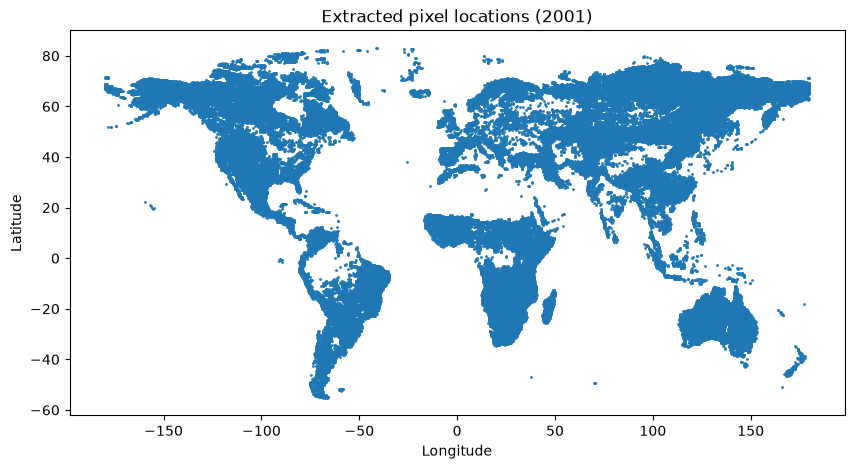

In [21]:
sample = df.sample(
    min(100000, df.height)
)


plt.figure(figsize=(10, 5))

plt.scatter(
    sample["longitude"],
    sample["latitude"],
    s=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Extracted pixel locations (2001)")

plt.show()

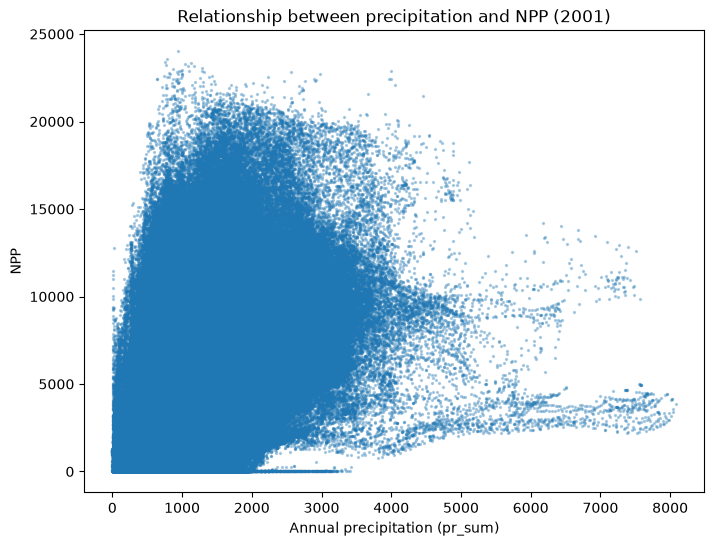

In [ ]:
# Random sample for plotting
plot_df = (
    df
    .select(["pr_sum", "Npp"])
    .drop_nulls()
    #.sample(n=min(100000, df.height), seed=42)
)


# Convert to numpy for matplotlib
x = plot_df["pr_sum"].to_numpy()
y = plot_df["Npp"].to_numpy()


# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    s=2,
    alpha=0.3
)

plt.xlabel("Annual precipitation (pr_sum)")
plt.ylabel("NPP")
plt.title("Relationship between precipitation and NPP (2002)")

plt.show()

In [23]:
df.select(
    pl.corr("pr_sum", "Npp")
)

pr_sum
f32
0.628272


## Inspect wgs84 raster stack

WGS84 raster stack
File:       stack_wgs84_2002.tif
Bands:      19
Dimensions: 8008 × 4004
CRS:        EPSG:4326
Resolution: (0.04495504495504495, 0.04495504495504495)
Nodata:     nan

Band  1: tmmn_mean
Band  2: tmmx_mean
Band  3: tmmn_min
Band  4: tmmn_max
Band  5: tmmx_min
Band  6: tmmx_max
Band  7: pr_sum
Band  8: veg_tmmn_mean
Band  9: veg_tmmx_mean
Band 10: veg_tmmn_min
Band 11: veg_tmmn_max
Band 12: veg_tmmx_min
Band 13: veg_tmmx_max
Band 14: veg_pr_sum
Band 15: vegetation_length
Band 16: Gpp
Band 17: Npp
Band 18: Npp_QC
Band 19: elevation_mean


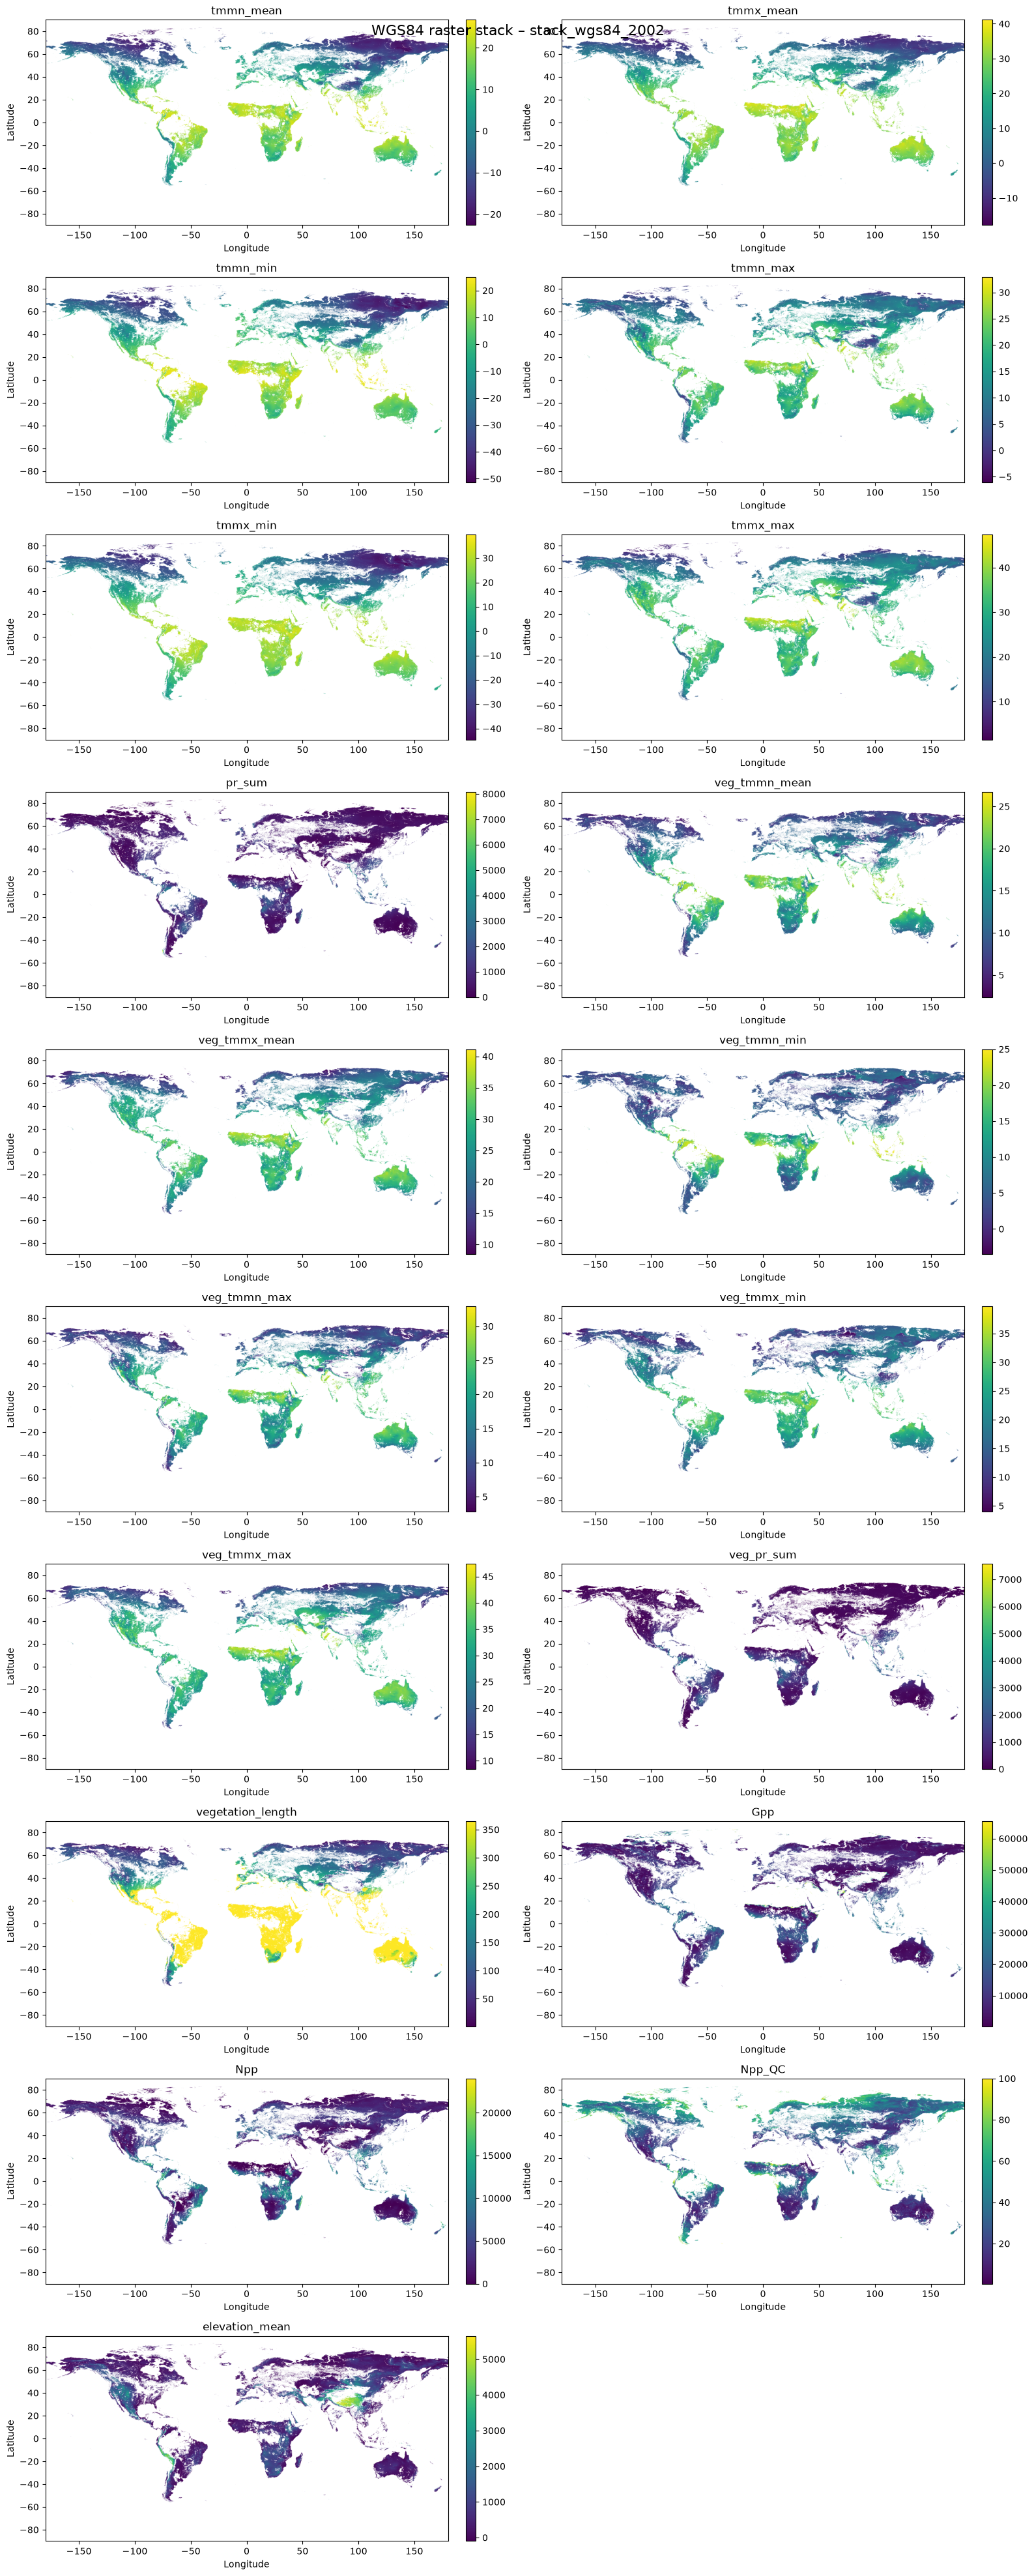

In [26]:
# ============================================================
# Inspect all bands of a WGS84 raster stack
# ============================================================



# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

path = Path("/Users/Wanja/Documents/non-equilibrium_data")

raster_path = (
    path
    / "rasters_wgs84_new"
    / "stack_wgs84_2002.tif"
)


# ------------------------------------------------------------
# 2. Open raster
# ------------------------------------------------------------

with rasterio.open(raster_path) as src:

    print("=" * 70)
    print("WGS84 raster stack")
    print("=" * 70)

    print(f"File:       {raster_path.name}")
    print(f"Bands:      {src.count}")
    print(f"Dimensions: {src.width} × {src.height}")
    print(f"CRS:        {src.crs}")
    print(f"Resolution: {src.res}")
    print(f"Nodata:     {src.nodata}")
    print()

    # --------------------------------------------------------
    # Band information
    # --------------------------------------------------------

    for i, name in enumerate(
        src.descriptions,
        start=1,
    ):

        print(
            f"Band {i:2d}: {name}"
        )

    # --------------------------------------------------------
    # Read all bands
    # --------------------------------------------------------

    data = src.read()

    # Raster extent
    bounds = src.bounds

    extent = [
        bounds.left,
        bounds.right,
        bounds.bottom,
        bounds.top,
    ]


# ------------------------------------------------------------
# 3. Create subplot grid
# ------------------------------------------------------------

n_bands = data.shape[0]

n_cols = 2
n_rows = int(np.ceil(n_bands / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows),
)

# Make axes iterable even if there is only one row
axes = np.atleast_1d(axes).ravel()


# ------------------------------------------------------------
# 4. Display each band
# ------------------------------------------------------------

for i in range(n_bands):

    ax = axes[i]

    band = data[i]

    name = src.descriptions[i]

    if name is None:
        name = f"Band {i + 1}"

    # Mask NaN values
    band = np.ma.masked_invalid(band)

    # Display raster
    im = ax.imshow(
        band,
        extent=extent,
        origin="upper",
        aspect="auto",
    )

    ax.set_title(name)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # Colorbar for each band
    fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )


# ------------------------------------------------------------
# 5. Remove unused subplots
# ------------------------------------------------------------

for i in range(n_bands, len(axes)):
    axes[i].set_visible(False)


# ------------------------------------------------------------
# 6. Overall layout
# ------------------------------------------------------------

fig.suptitle(
    f"WGS84 raster stack – {raster_path.stem}",
    fontsize=16,
)

plt.tight_layout()

plt.show()